In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/superstore.csv')

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [22]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [24]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [25]:
df['Order Date']=pd.to_datetime(df['Order Date'],errors="coerce", dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Order Date'],errors="coerce", dayfirst=True)
df.drop(columns=['Postal Code'],inplace=True)


In [26]:
df.columns=df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'region', 'product_id', 'category', 'sub-category', 'product_name',
       'sales'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9800 non-null   int64         
 1   order_id       9800 non-null   object        
 2   order_date     9800 non-null   datetime64[ns]
 3   ship_date      9800 non-null   datetime64[ns]
 4   ship_mode      9800 non-null   object        
 5   customer_id    9800 non-null   object        
 6   customer_name  9800 non-null   object        
 7   segment        9800 non-null   object        
 8   country        9800 non-null   object        
 9   city           9800 non-null   object        
 10  state          9800 non-null   object        
 11  region         9800 non-null   object        
 12  product_id     9800 non-null   object        
 13  category       9800 non-null   object        
 14  sub-category   9800 non-null   object        
 15  product_name   9800 n

In [29]:
df['order_year']=df['order_date'].dt.year
df['order_month']=df['order_date'].dt.month
df['order_month_name']=df['order_date'].dt.month_name()

In [30]:
total_sales=df['sales'].sum()
total_sales

2261536.7827000003

In [32]:
sales_by_region=df.groupby('region')['sales'].sum().sort_values(ascending=False)
sales_by_region

region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

In [33]:
sales_by_category=df.groupby('category')['sales'].sum()
sales_by_category

category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: sales, dtype: float64

In [39]:
monthly_sales=df.groupby('order_month')['sales'].sum()
monthly_sales

order_month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: sales, dtype: float64

In [40]:
top_products=df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

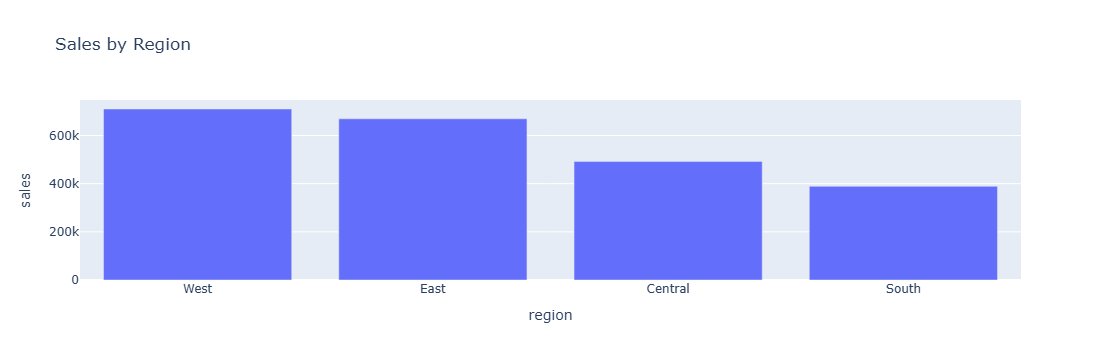

In [46]:
import plotly.express as px
fig=px.bar(sales_by_region,
          x=sales_by_region.index,
          y='sales',
          title='Sales by Region')
fig.show()

In [ ]:
#The West region generates the highest sales, exceeding 600K, indicating strong market performance. In contrast, the South region records the lowest sales, around 400K, suggesting potential underperformance or lower demand in that region

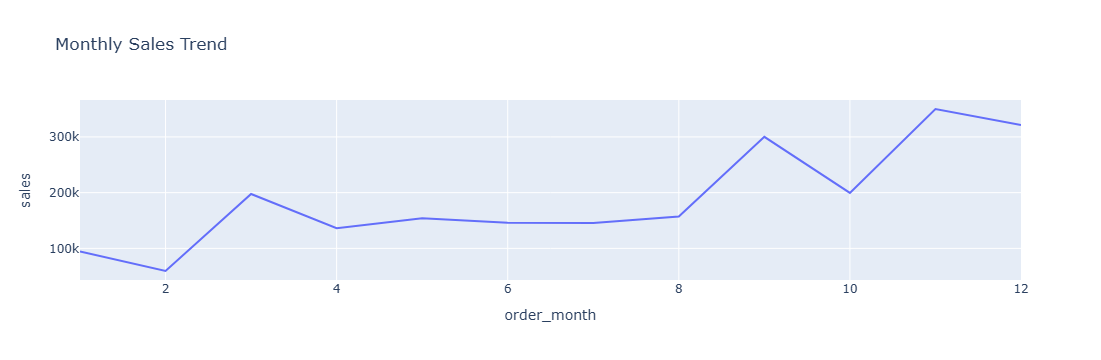

In [48]:
fig=px.line(monthly_sales,
          x=monthly_sales.index,
          y='sales',
          title='Monthly Sales Trend')
fig.show()

In [49]:
#Sales show a clear upward trend toward the end of the year, peaking in the final months (November–December) at over 300K. This suggests strong seasonality, likely driven by holiday demand and promotional periods.

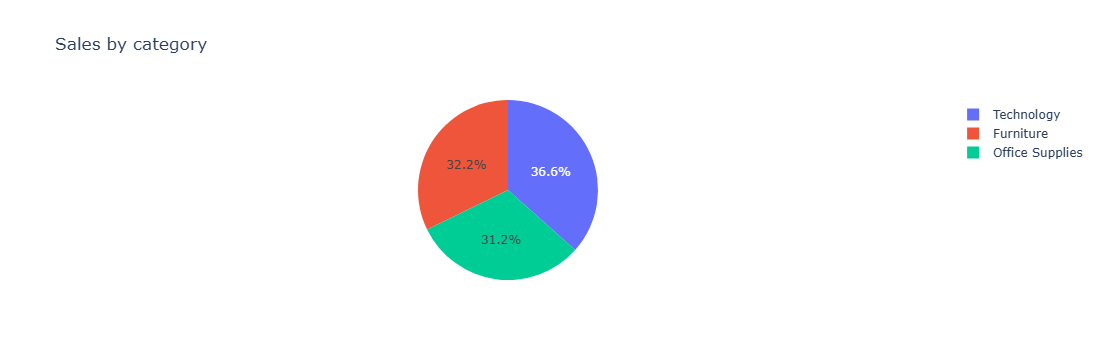

In [52]:
fig=px.pie(values=sales_by_category.values,
          names=sales_by_category.index,
          title='Sales by category')
fig.show()

In [ ]:
#Category Performance
#Technology contributes the highest share of total sales, indicating strong customer demand for tech-related products. This suggests that the business should prioritize this category for marketing and inventory planning

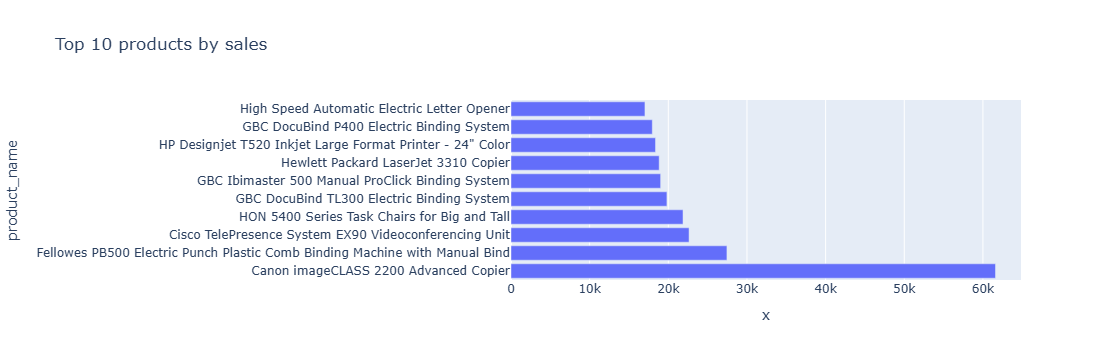

In [54]:
fig=px.bar(top_products,
          x=top_products.values,
          y=top_products.index,
          orientation='h',
          title='Top 10 products by sales')
fig.show()

In [ ]:
#Top Products
#A small number of products contribute significantly to overall revenue. For example, the Canon ImageCLASS 2200 Advanced Copier is among the top-performing products, highlighting a concentration of sales in high-value items.